# CS 437 - Deep Learning

# PA6 Part 1 - Neural Network Compression: Pruning & Knowledge Distillation

---

**Instructions:** Read every cell carefully before running it. Do **not** modify cells that are marked # DO NOT MODIFY. 

---

## Learning Objectives
By the end of this assignment you will be able to:
- Implement L1/L2 magnitude-based **unstructured** and **structured (channel-wise)** pruning from scratch on a ResNet.
- Train a student model via **Logit Matching**, **FitNets (Hint)** distillation, and understand when each is preferred.
- Reason critically about hardware implications, sensitivity, and the interplay between all two compression families.

---

## Grading Breakdown

| Task | Marks |
|------|-------|
| Task 1 – Pruning | 30 |
| Task 2 – Knowledge Distillation | 30 |
| Task 3 - Combination Lab | 30 |
| Task 4 - Analysis | 10
| **Total** | **100** |

---

## Environment Setup

### Required Libraries

Run the cell below **first** before anything else. It installs all third-party packages needed for this notebook. Pre-installed packages (`torch`, `torchvision`, `numpy`) are already available on Colab/Kaggle and do not need to be re-installed.

| Package | Version | Purpose |
|---------|---------|--------|
| `torch` | ≥ 2.1 | Core deep learning framework (pre-installed) |
| `torchvision` | ≥ 0.16 | Datasets, transforms, pretrained models (pre-installed) |
| `grad-cam` | latest | Grad-CAM heatmap visualizations (`pytorch_grad_cam`) |
| `matplotlib` | ≥ 3.7 | Plotting (usually pre-installed; upgraded here) |
| `seaborn` | ≥ 0.12 | Statistical visualizations |
| `scikit-image` | ≥ 0.21 | SSIM for Grad-CAM similarity scoring |
| `tqdm` | ≥ 4.65 | Progress bars for training loops |
| `numpy` | ≥ 1.24 | Numerical utilities (pre-installed) |
| `opencv-python-headless` | latest | Image processing for Grad-CAM overlays |

<br>


In [1]:
# ── Step 1: Install all required packages ────────────────────────────────────
# Run this cell first. It is safe to re-run — already-installed packages
# will simply be skipped or confirmed.

!pip install -q grad-cam                     # Grad-CAM visualizations (pytorch_grad_cam)
!pip install -q scikit-image                 # SSIM for heatmap similarity
!pip install -q opencv-python-headless       # Image overlays used by grad-cam
!pip install -q seaborn                      # Statistical plots
!pip install -q tqdm                         # Progress bars
!pip install -q matplotlib --upgrade         # Ensure recent version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 67.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.9 which is incompatible.


In [2]:
# ── Step 2: Verify environment ───────────────────────────────────────────────
# DO NOT MODIFY — confirms GPU availability and key package versions
import torch, torchvision, numpy, matplotlib, seaborn, skimage

print(f"PyTorch        : {torch.__version__}")
print(f"Torchvision    : {torchvision.__version__}")
print(f"NumPy          : {numpy.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {seaborn.__version__}")
print(f"scikit-image   : {skimage.__version__}")
print()
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Training will be very slow. Enable GPU in Runtime settings.")

PyTorch        : 2.10.0+cu128
Torchvision    : 0.25.0+cu128
NumPy          : 2.0.2
Matplotlib     : 3.10.0
Seaborn        : 0.13.2
scikit-image   : 0.25.2

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


In [3]:
# DO NOT MODIFY — shared imports used throughout the notebook
import os, copy, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED       = 42
NUM_CLASSES = 100
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Running on: {DEVICE}")

Running on: cuda


## Shared Utilities — Data & Baseline Model

We use **CIFAR-100** throughout. A pre-trained **ResNet-34** (trained for ~50 epochs with standard augmentation) serves as the baseline. Helper functions for training, evaluation and visualisation are provided below — you will call these throughout the assignment.

In [4]:
# DO NOT MODIFY — data loaders
MEAN = (0.5071, 0.4867, 0.4408)
STD  = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = torchvision.datasets.CIFAR100(root="./data", train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Smaller subset for fast fine-tuning after compression
finetune_dataset = Subset(train_dataset, indices=list(range(10000)))
finetune_loader  = DataLoader(finetune_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)} | Finetune subset: {len(finetune_dataset)}")

100%|██████████| 169M/169M [05:04<00:00, 556kB/s]


Train: 50000 | Test: 10000 | Finetune subset: 10000


In [5]:
# DO NOT MODIFY — shared training / evaluation utilities
def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct += outputs.argmax(1).eq(targets).sum().item()
        total   += inputs.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        correct += outputs.argmax(1).eq(targets).sum().item()
        total   += inputs.size(0)
    return 100.0 * correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def count_nonzero_params(model):
    return sum(p.nonzero().size(0) for p in model.parameters())


def model_size_mb(model):
    tmp = "/tmp/_tmp_model.pt"
    torch.save(model.state_dict(), tmp)
    size = os.path.getsize(tmp) / 1e6
    os.remove(tmp)
    return size


def measure_inference_time(model, n_runs=50, batch_size=64):
    model.eval()
    dummy = torch.randn(batch_size, 3, 32, 32).to(DEVICE)
    # Warm-up
    for _ in range(50):
        with torch.no_grad():
            _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        with torch.no_grad():
            _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / n_runs * 1000  # ms per batch
    return elapsed


print("Utilities loaded.")

Utilities loaded.


In [6]:
# DO NOT MODIFY — build & train (or load) baseline ResNet-34
def build_resnet34(num_classes=100, pretrained_imagenet=False):
    if pretrained_imagenet:
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    else:
        model = models.resnet34(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


CHECKPOINT = "resnet34_cifar100_baseline.pt"

# TODO: build and train the baseline ResNet-34 model.
baseline_model = build_resnet34(NUM_CLASSES, pretrained_imagenet=True).to(DEVICE)

if os.path.exists(CHECKPOINT):
    baseline_model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
    print("Loaded baseline checkpoint.")
else:
    print("Training baseline ResNet-34 (50 epochs) — grab a coffee...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(baseline_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
    scaler    = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    for epoch in range(50):
        loss, tr_acc = train_one_epoch(baseline_model, train_loader, optimizer, criterion, scaler)
        scheduler.step()
        if (epoch + 1) % 5 == 0:
            val_acc = evaluate(baseline_model, test_loader)
            print(f"  Epoch {epoch+1:02d} | loss={loss:.3f} | train={tr_acc:.1f}% | val={val_acc:.1f}%")
    torch.save(baseline_model.state_dict(), CHECKPOINT)
    print("Baseline training complete.")

BASELINE_ACC = evaluate(baseline_model, test_loader)
print(f"\nBaseline accuracy : {BASELINE_ACC:.2f}%")
print(f"Parameters        : {count_params(baseline_model):,}")
print(f"Model size        : {model_size_mb(baseline_model):.2f} MB")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 194MB/s]


Training baseline ResNet-34 (50 epochs) — grab a coffee...
  Epoch 05 | loss=1.497 | train=57.4% | val=54.0%
  Epoch 10 | loss=1.150 | train=66.2% | val=55.0%
  Epoch 15 | loss=0.903 | train=72.5% | val=57.9%
  Epoch 20 | loss=0.680 | train=78.8% | val=58.9%
  Epoch 25 | loss=0.424 | train=86.7% | val=60.8%
  Epoch 30 | loss=0.230 | train=92.9% | val=62.2%
  Epoch 35 | loss=0.116 | train=96.7% | val=63.0%
  Epoch 40 | loss=0.058 | train=98.5% | val=64.0%
  Epoch 45 | loss=0.040 | train=99.0% | val=64.5%
  Epoch 50 | loss=0.038 | train=99.2% | val=64.5%
Baseline training complete.

Baseline accuracy : 64.47%
Parameters        : 21,335,972
Model size        : 85.49 MB


---
# Task 1 — Pruning (30 marks)

Pruning removes redundant weights or entire structures from a trained network. We explore two variants:

| Variant | What is removed | Effect on weight tensors |
|---------|-----------------|-------------------------|
| **Unstructured** | Individual weights | Sparse tensors; same shape |
| **Structured (channel-wise)** | Entire output filters | Smaller tensors; requires reshaping |

We use a **pre-trained ResNet-34** (from the previous section) throughout Task 1.

---
### Background reading (required before coding)
- Han et al. (2015) *Learning both Weights and Connections for Efficient Neural Networks*
- Li et al. (2017) *Pruning Filters for Efficient ConvNets*

---

## 1.1 — Unstructured Pruning (10 marks)

In **unstructured pruning** we zero out the smallest-magnitude weights globally (or per-layer). The tensor shapes do **not** change; zeros are simply masked out. A real deployment would store the sparse representation, but for this exercise we track the sparsity ratio analytically.

**Your tasks:**
1. `(3 pts)` Implement `get_global_threshold` — finds the weight magnitude threshold such that exactly `sparsity` fraction of all conv/linear weights fall below it.
2. `(3 pts)` Implement `apply_unstructured_pruning` — zeros all weights below the threshold and stores the binary mask.
3. `(2 pts)` Plot weight distributions before and after pruning and comment on the shape of the distribution.
4. `(2 pts)` Run a layer-wise sensitivity analysis: for each Conv/Linear layer independently set sparsity ∈ {0.1, 0.3, 0.5, 0.7, 0.9} and record the drop in validation accuracy. Plot and discuss which layers are most sensitive.

In [7]:
# ── SOLUTION ─────────────────────────────────────────────────────────────────
# Helper: collect all prunable weight tensors from conv and linear layers
def get_prunable_params(model):
    """Return list of (name, weight_tensor) for all Conv2d and Linear layers."""
    params = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            params.append((name, module.weight.data))
    return params


# --------------------------------------------------------------------------
# TODO 1.1.a — implement get_global_threshold
# --------------------------------------------------------------------------
def get_global_threshold(model, sparsity: float) -> float:
    """
    Compute the magnitude threshold T such that exactly `sparsity`
    fraction of all conv/linear weights have |w| < T.

    Args:
        model    : a PyTorch nn.Module
        sparsity : float in [0, 1)
    Returns:
        T        : scalar threshold

    Hint: concatenate all weight magnitudes into a single 1-D tensor,
          then use torch.quantile.
    """

    all_weights = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            all_weights.append(module.weight.data.abs().view(-1))
    
    all_weights_tensor = torch.cat(all_weights)
    sorted_weights, _ = torch.sort(all_weights_tensor)
    k = int(sparsity * sorted_weights.numel())
    k = min(k, sorted_weights.numel() - 1)
    
    threshold = sorted_weights[k].item()
    return threshold

# --------------------------------------------------------------------------
# TODO 1.1.b — implement apply_unstructured_pruning
# --------------------------------------------------------------------------
def apply_unstructured_pruning(model, sparsity: float):
    """
    Prune the model in-place by zeroing weights below the global threshold.
    Store masks as buffer `<layer_name>_mask` on the model so that zeros
    can be reapplied after fine-tuning (crucial for iterative pruning).

    Args:
        model    : nn.Module (modified in-place)
        sparsity : target fraction of zeros
    Returns:
        actual_sparsity : float — fraction of zeros actually achieved

    Hint: threshold = get_global_threshold(model, sparsity)
          mask = (|w| >= threshold).float()
          w *= mask
    """
    threshold = get_global_threshold(model, sparsity)
    total_params = 0
    zeros_count = 0
    
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            mask = (module.weight.data.abs() >= threshold).float()
            module.weight.data.mul_(mask)
            
            safe_name = name.replace('.', '_') + '_mask'
            module.register_buffer(safe_name, mask)
            
            total_params += module.weight.numel()
            zeros_count += (mask == 0).sum().item()
            
    actual_sparsity = zeros_count / total_params if total_params > 0 else 0.0
    return actual_sparsity


def reapply_masks(model):
    """After a fine-tuning step, re-zero weights where mask == 0."""
    buffers = dict(model.named_buffers())
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            safe_name = name.replace('.', '_') + '_mask'
            if safe_name in buffers:
                module.weight.data *= buffers[safe_name]

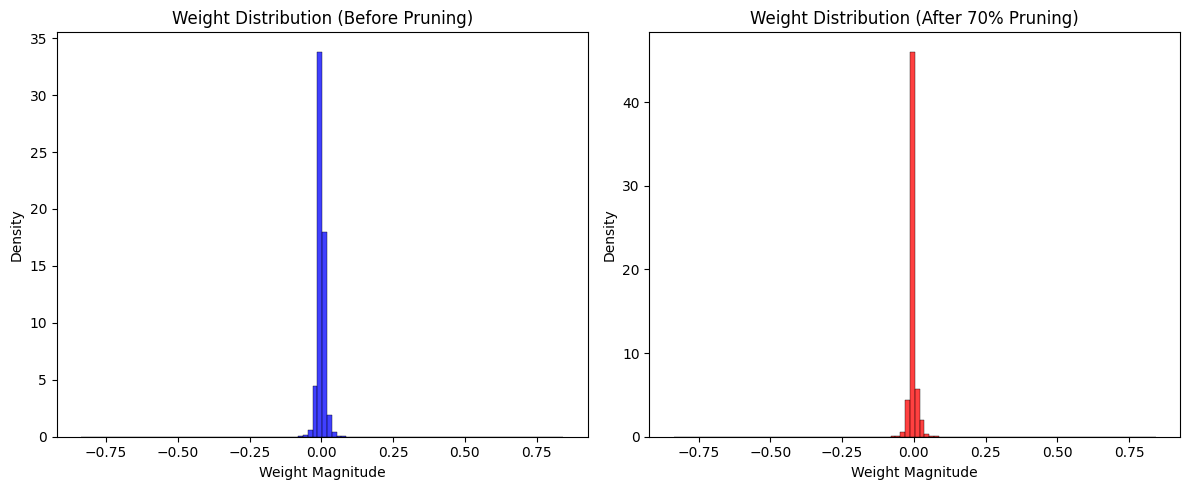

In [8]:
# ── YOUR CODE HERE — weight distribution plots ─────────────────────────────────────
# TODO 1.1.c — produce before/after weight distribution plots

baseline_weights = []
for _, w in get_prunable_params(baseline_model):
    baseline_weights.append(w.cpu().view(-1))
baseline_weights = torch.cat(baseline_weights).numpy()
unstructured_model = copy.deepcopy(baseline_model)
apply_unstructured_pruning(unstructured_model, sparsity=0.7)
pruned_weights = []
for _, w in get_prunable_params(unstructured_model):
    pruned_weights.append(w.cpu().view(-1))
pruned_weights = torch.cat(pruned_weights).numpy()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(baseline_weights, bins=100, ax=axs[0], color='blue', stat='density')
axs[0].set_title("Weight Distribution (Before Pruning)")
axs[0].set_xlabel("Weight Magnitude")

sns.histplot(pruned_weights, bins=100, ax=axs[1], color='red', stat='density')
axs[1].set_title("Weight Distribution (After 70% Pruning)")
axs[1].set_xlabel("Weight Magnitude")
plt.tight_layout()
plt.show()

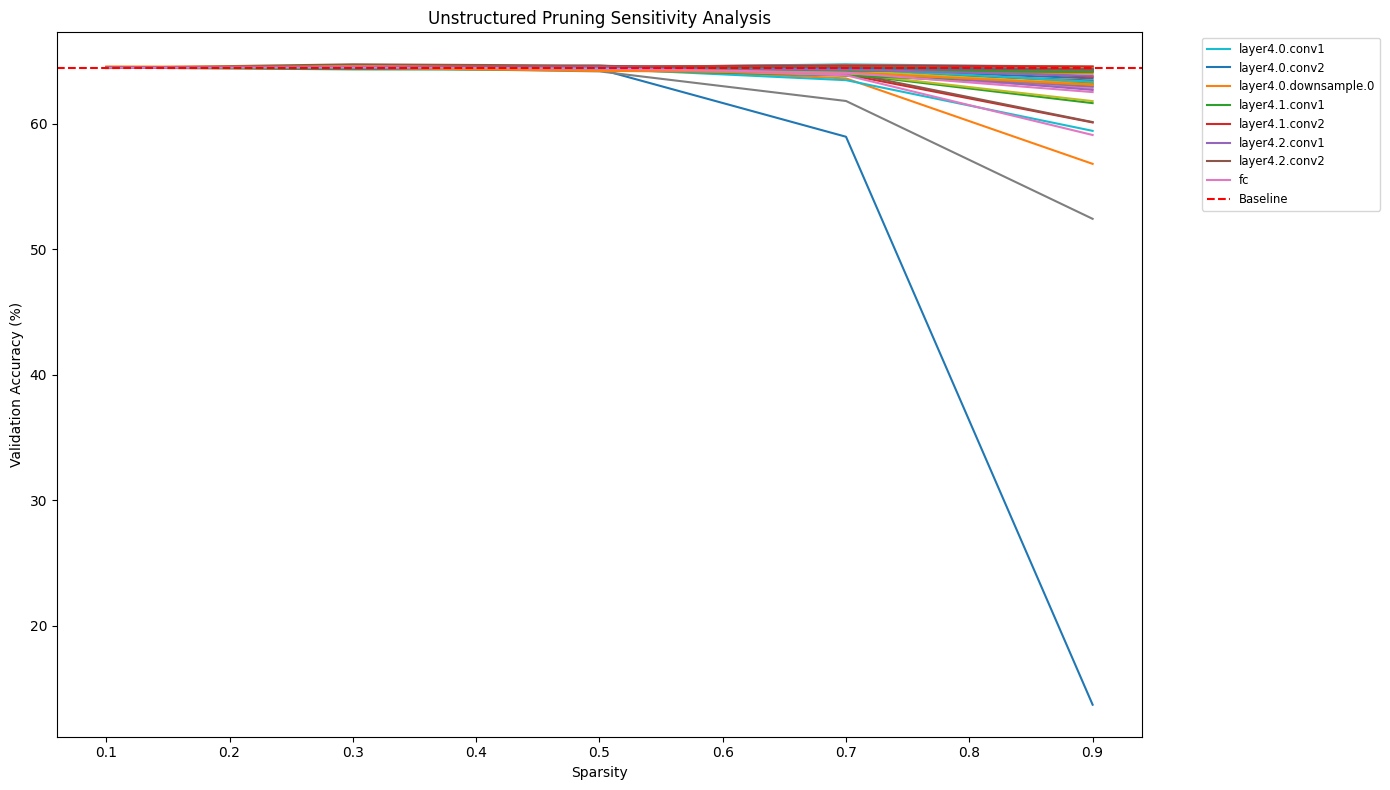

In [9]:
# ── YOUR CODE HERE — layer-wise sensitivity analysis ────────────────────────────────
# TODO 1.1.d — sensitivity analysis
# For each Conv2d / Linear layer, independently prune ONLY that layer
# at each sparsity level and record the validation accuracy.

sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
sensitivity_results = {}

for name, original_weight in get_prunable_params(baseline_model):
    layer_accuracies = []
    module = dict(baseline_model.named_modules())[name]
    
    for s in sparsities:
        orig_data = module.weight.data.clone()
        threshold = torch.quantile(orig_data.abs().view(-1), s).item()
        mask = (orig_data.abs() >= threshold).float()
        module.weight.data.mul_(mask)
        acc = evaluate(baseline_model, test_loader)
        layer_accuracies.append(acc)
        module.weight.data = orig_data
        
    sensitivity_results[name] = layer_accuracies

plt.figure(figsize=(14, 8))
for name, accs in sensitivity_results.items():
    plt.plot(sparsities, accs, label=name if 'layer4' in name or 'fc' in name else "")
plt.axhline(y=BASELINE_ACC, color='r', linestyle='--', label='Baseline')
plt.xlabel("Sparsity")
plt.ylabel("Validation Accuracy (%)")
plt.title("Unstructured Pruning Sensitivity Analysis")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

### Analysis 1.1 — *Your written answer here*

*Explain:*
1. *Why does the weight distribution have a bell-curve shape, and why does pruning mainly affect weights near zero?*

The weights naturally form that tight bell curve centered around zero because of L2 regularization (weight decay) during training, which actively penalizes large weights to keep the model from overfitting. Magnitude-based pruning targets the weights nearest to zero under the assumption that smaller values contribute the least to the final activations. we can see this exactly in our second histogram where the massive red spike right at exactly 0.0 represents the 70% of tiny weights that were masked out, while the heavier tails of the distribution were left intact.



2. *Which layers are most sensitive to pruning? Are they early or late layers? Why might this be the case given their role in feature extraction?*


Looking straight at the sensitivity graph, the late layers are massively more sensitive to pruning. The blue line (layer4.0.conv2) absolutely tanks, dropping to around 13% accuracy at 0.9 sparsity, while the grey (layer4.2.conv2) and orange (layer4.0.downsample.0) lines also show severe degradation.

Early layers usually extract highly redundant, basic features (like edges and colors), meaning the network can afford to lose a chunk of those parameters without forgetting how to see. Late layers (like the layer4 block) contain highly specialized, high-level representations that feed directly into the final classifier. When you aggressively prune those bottlenecks, the network completely loses its ability to distinguish between complex classes.



3. *What are the implications of masking weights to zero vs. physically removing them in terms of memory and compute?*

Masking to zero (Unstructured): This just replaces small values with 0.0. The tensor's shape and size remain completely unchanged. Unless we are using specialized sparse-matrix libraries or hardware, standard GPUs will still store those zeros in memory and still waste compute cycles calculating $0 \times X = 0$. It is essentially "simulated" sparsity.

Physically removing (Structured): By dropping entire filters or channels, you actually shrink the dimensions of the weight tensors. This provides genuine, immediate reductions in both the memory footprint and the computational cost, since the underlying dense matrix multiplications are now physically smaller.

## 1.2 — Structured (Channel-wise) Pruning (10 marks)

**Structured pruning** removes entire output channels (filters) from a convolutional layer. Because an output channel of layer *l* is an input channel of layer *l+1*, these pruning decisions are **coupled**: removing filter *i* in layer *l* also removes the *i*-th input channel slice in layer *l+1*. This makes the resulting network physically smaller — no need for sparse representations.

We measure a filter's importance by the **L1-norm of its weight tensor** (summed over spatial dimensions).

**Your tasks:**
1. `(4 pts)` Implement `structured_prune_resnet` that:
   - Computes per-filter L1 norms for every `Conv2d` layer.
   - Retains the top-`(1 - sparsity)` fraction of filters.
   - Rebuilds the `nn.Conv2d` and next conv/BN with the correct reduced dimensions.
2. `(3 pts)` Repeat the sensitivity analysis for structured pruning and compare the trend against unstructured.
3. `(3 pts)` Fine-tune the 70%-pruned structured model for 50 epochs and report recovered accuracy.

> **Note on ResNet residual connections:** Residual shortcuts add the input to the block output. When pruning channels within a residual block you must ensure the shortcut projection (if present) is also updated consistently. For simplicity, **skip pruning of the first conv in each residual block** (treat it as sensitive) and only prune the second conv. A comment explaining this design choice will be graded.

In [10]:
# ── YOUR CODE HERE — structured pruning ────────────────────────────────────────────
# TODO 1.2.1

def structured_prune_resnet(model, sparsity: float):
    for name, module in model.named_modules():
        if isinstance(module, torchvision.models.resnet.BasicBlock):
            conv1 = module.conv1
            bn1 = module.bn1
            conv2 = module.conv2
            
            l1_norms = conv1.weight.data.abs().sum(dim=(1, 2, 3))
            num_keep = int(conv1.out_channels * (1.0 - sparsity))
            if num_keep == 0:
                num_keep = 1
                
            _, keep_indices = torch.topk(l1_norms, num_keep)
            keep_indices = keep_indices.sort()[0]
            
            conv1.out_channels = num_keep
            conv1.weight = nn.Parameter(conv1.weight.data[keep_indices])
            
            bn1.num_features = num_keep
            bn1.weight = nn.Parameter(bn1.weight.data[keep_indices])
            bn1.bias = nn.Parameter(bn1.bias.data[keep_indices])
            bn1.running_mean = bn1.running_mean[keep_indices]
            bn1.running_var = bn1.running_var[keep_indices]
            
            conv2.in_channels = num_keep
            conv2.weight = nn.Parameter(conv2.weight.data[:, keep_indices])

structured_model = copy.deepcopy(baseline_model)
structured_prune_resnet(structured_model, sparsity=0.7)

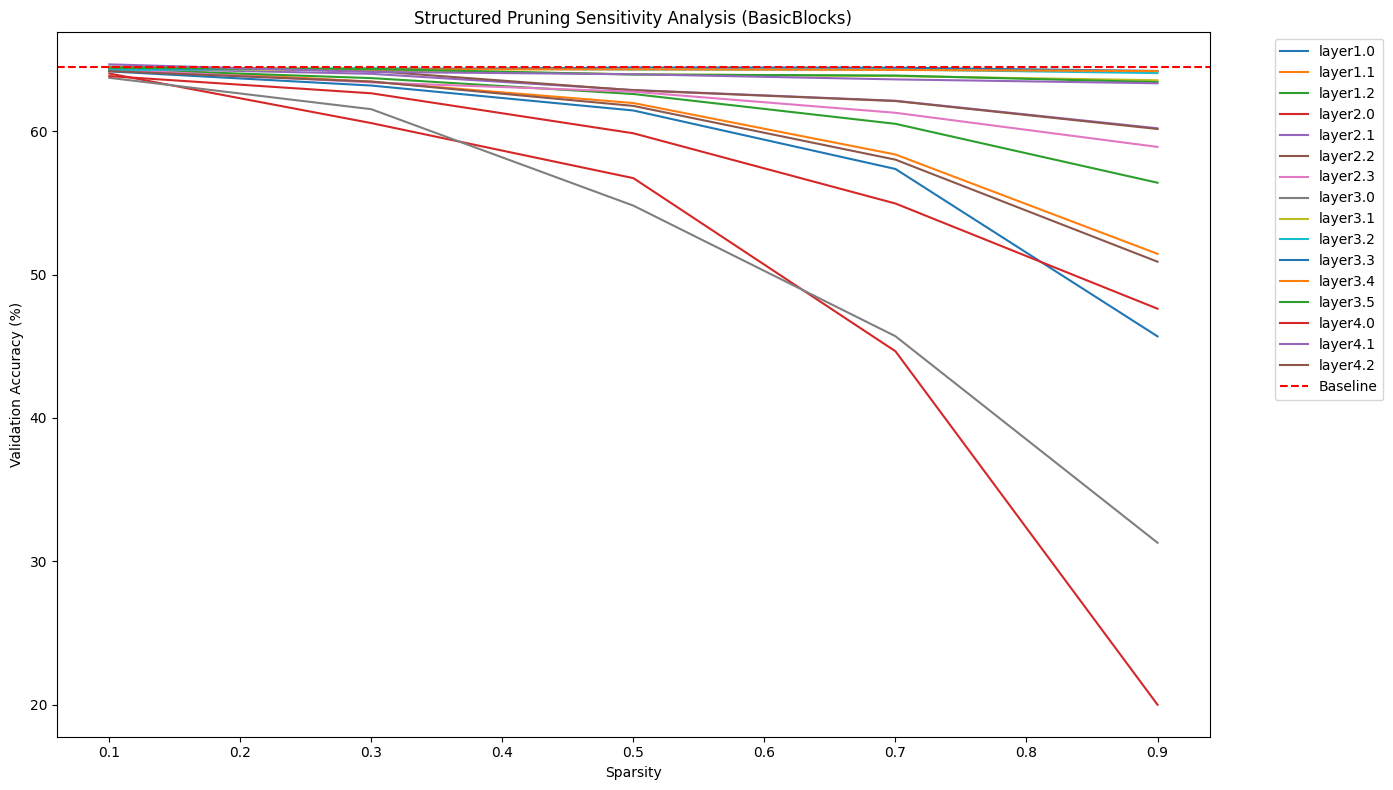

In [11]:
# ── YOUR CODE HERE — structured sensitivity analysis ────────────────────────────────
# TODO 1.2.2

structured_sensitivity_results = {}

for name, module in baseline_model.named_modules():
    if isinstance(module, torchvision.models.resnet.BasicBlock):
        layer_accuracies = []
        for s in sparsities:
            temp_model = copy.deepcopy(baseline_model)
            temp_block = dict(temp_model.named_modules())[name]
            conv1 = temp_block.conv1
            bn1 = temp_block.bn1
            conv2 = temp_block.conv2
            l1_norms = conv1.weight.data.abs().sum(dim=(1, 2, 3))
            num_keep = max(1, int(conv1.out_channels * (1.0 - s)))
            _, keep_indices = torch.topk(l1_norms, num_keep)
            keep_indices = keep_indices.sort()[0]
            conv1.out_channels = num_keep
            conv1.weight = nn.Parameter(conv1.weight.data[keep_indices])
            bn1.num_features = num_keep
            bn1.weight = nn.Parameter(bn1.weight.data[keep_indices])
            bn1.bias = nn.Parameter(bn1.bias.data[keep_indices])
            bn1.running_mean = bn1.running_mean[keep_indices]
            bn1.running_var = bn1.running_var[keep_indices]
            conv2.in_channels = num_keep
            conv2.weight = nn.Parameter(conv2.weight.data[:, keep_indices])
            
            acc = evaluate(temp_model, test_loader)
            layer_accuracies.append(acc)
            
        structured_sensitivity_results[name] = layer_accuracies

plt.figure(figsize=(14, 8))
for name, accs in structured_sensitivity_results.items():
    plt.plot(sparsities, accs, label=name)
plt.axhline(y=BASELINE_ACC, color='r', linestyle='--', label='Baseline')
plt.xlabel("Sparsity")
plt.ylabel("Validation Accuracy (%)")
plt.title("Structured Pruning Sensitivity Analysis (BasicBlocks)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# ── YOUR CODE HERE — fine-tuning the 70%-pruned structured model ────────────────────
# TODO 1.2.3

structured_model = structured_model.to(DEVICE)
criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(structured_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=50)
scaler_ft = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
for epoch in range(50):
    loss, tr_acc = train_one_epoch(structured_model, finetune_loader, optimizer_ft, criterion_ft, scaler_ft)
    scheduler_ft.step()
    if (epoch + 1) % 10 == 0:
        val_acc = evaluate(structured_model, test_loader)
        print(f"  Finetune Epoch {epoch+1:02d} | loss={loss:.3f} | train={tr_acc:.1f}% | val={val_acc:.1f}%")

FINETUNED_STRUCTURED_ACC = evaluate(structured_model, test_loader)
print(f"Recovered Structured Accuracy: {FINETUNED_STRUCTURED_ACC:.2f}%")

  Finetune Epoch 10 | loss=0.659 | train=80.4% | val=50.9%
  Finetune Epoch 20 | loss=0.305 | train=91.8% | val=52.0%
  Finetune Epoch 30 | loss=0.176 | train=95.8% | val=53.0%
  Finetune Epoch 40 | loss=0.143 | train=96.9% | val=52.6%
  Finetune Epoch 50 | loss=0.121 | train=97.5% | val=52.8%
Recovered Structured Accuracy: 52.83%


## 1.3 — Grad-CAM Comparison (10 marks)

Grad-CAM produces class-discriminative heatmaps that show *where* a model looks when making a prediction. Comparing Grad-CAM outputs for the baseline vs. pruned models reveals whether pruning preserves the model's spatial reasoning.

**Your tasks:**
1. `(4 pts)` Generate Grad-CAM heatmaps for 4 test images using **(a) baseline, (b) unstructured-pruned, (c) structured-pruned** models. Arrange them as a 3×4 grid.
2. `(3 pts)` Quantify similarity between teacher and pruned Grad-CAMs using **Structural Similarity Index (SSIM)** or **cosine similarity** on the heatmap tensors. Report the mean ± std.
3. `(3 pts)` Compare inference latency and on-disk model size for all three models. Fill the results table.

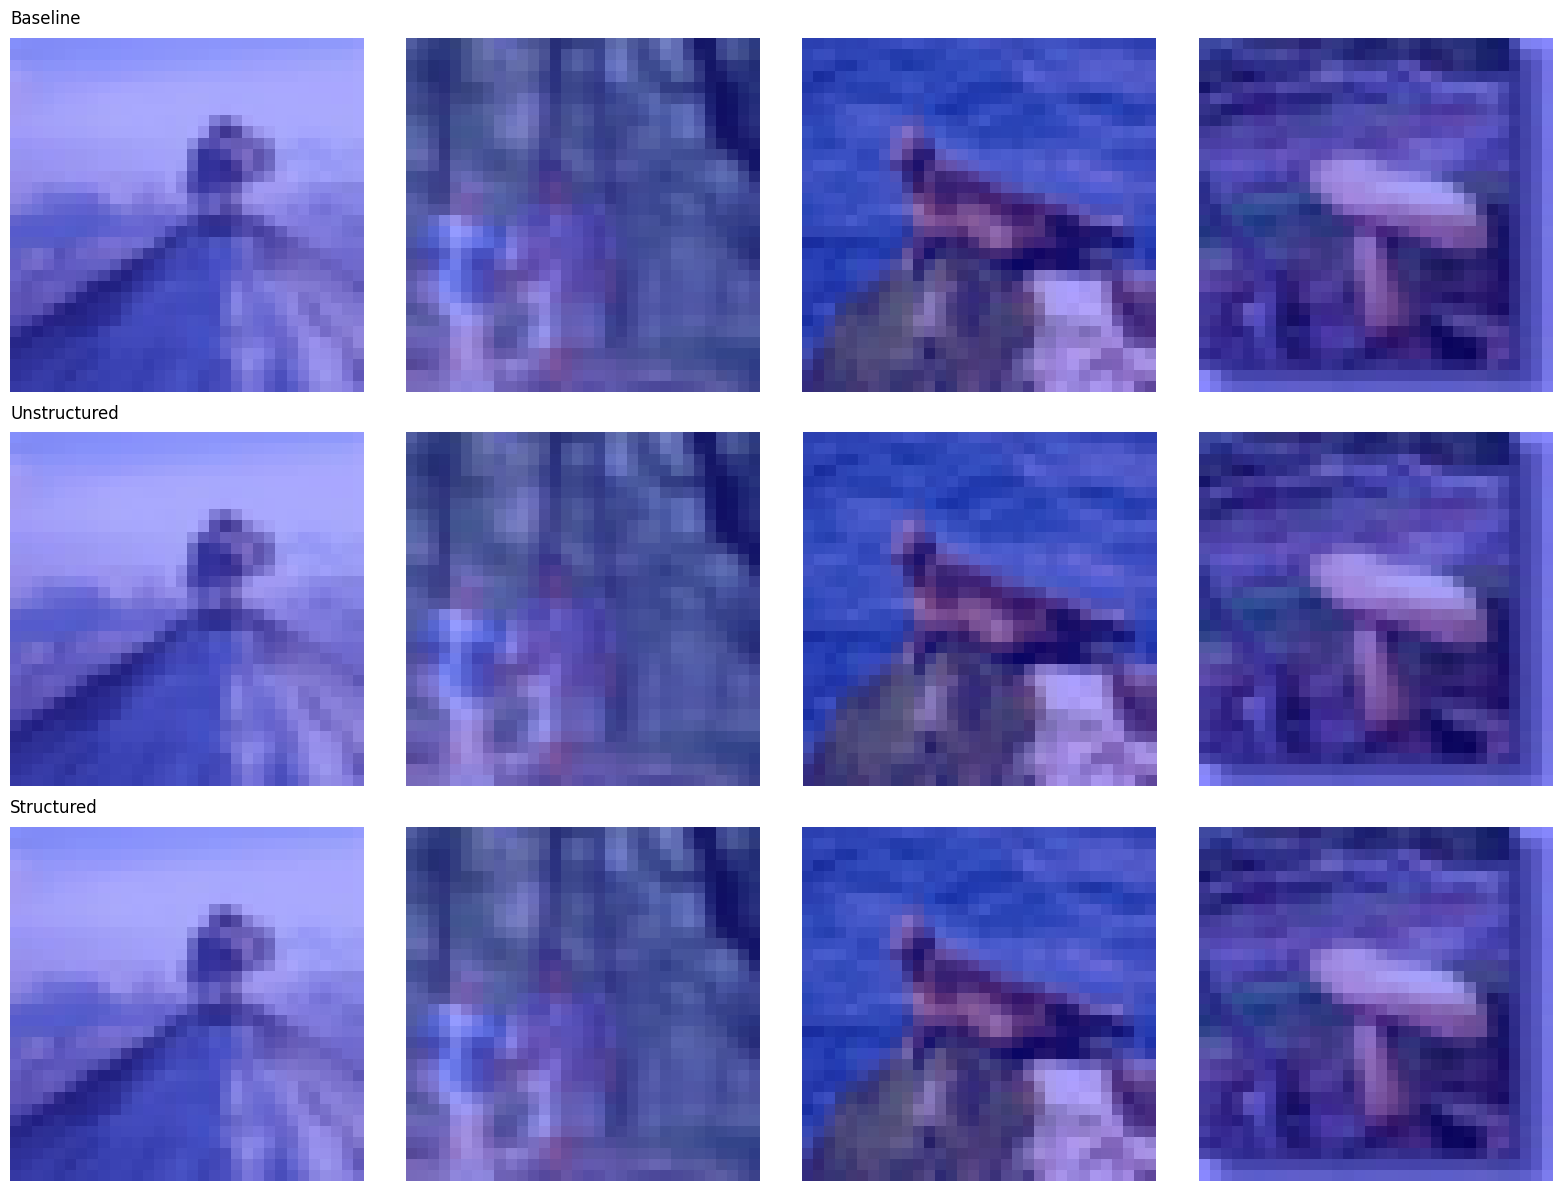

In [13]:
# ── YOUR CODE HERE — Grad-CAM visualisation ────────────────────────────────────────
# TODO 1.3.1
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from skimage.metrics import structural_similarity as ssim
import cv2

models_to_test = [
    ("Baseline", baseline_model),
    ("Unstructured", unstructured_model),
    ("Structured", structured_model)
]

def get_cam_image(model, input_tensor, rgb_img):
    target_layers = [model.layer4[-1].conv2]
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return visualization, grayscale_cam

test_iter = iter(test_loader)
images, labels = next(test_iter)
sample_images = images[:4].to(DEVICE)

fig, axs = plt.subplots(3, 4, figsize=(16, 12))

cams_data = {"Baseline": [], "Unstructured": [], "Structured": []}

for i in range(4):
    img_tensor = sample_images[i].unsqueeze(0)
    
    img_np = img_tensor.cpu().squeeze().numpy().transpose(1, 2, 0)
    img_np = STD * img_np + MEAN
    img_np = np.clip(img_np, 0, 1)
    
    for row, (name, mod) in enumerate(models_to_test):
        mod.eval()
        vis, grayscale = get_cam_image(mod, img_tensor, img_np)
        cams_data[name].append(grayscale)
        
        axs[row, i].imshow(vis)
        axs[row, i].axis('off')
        if i == 0:
            axs[row, i].set_title(name, loc='left', pad=10)

plt.tight_layout()
plt.show()

In [14]:
# ── YOUR CODE HERE — heatmap similarity + inference benchmark ──────────────────────
# TODO 1.3.2/1.3.3
ssim_unstructured = []
ssim_structured = []
for i in range(4):
    base_cam = cams_data["Baseline"][i]
    unstruct_cam = cams_data["Unstructured"][i]
    struct_cam = cams_data["Structured"][i]
    ssim_unstructured.append(ssim(base_cam, unstruct_cam, data_range=1.0))
    ssim_structured.append(ssim(base_cam, struct_cam, data_range=1.0))

print(f"SSIM (Baseline vs Unstructured): {np.mean(ssim_unstructured):.4f} ± {np.std(ssim_unstructured):.4f}")
print(f"SSIM (Baseline vs Structured): {np.mean(ssim_structured):.4f} ± {np.std(ssim_structured):.4f}")

print("\n Inference Benchmark: ")
for name, mod in models_to_test:
    inf_time = measure_inference_time(mod)
    size_mb = model_size_mb(mod)
    print(f"{name:15s} | Time: {inf_time:.2f} ms/batch | Size: {size_mb:.2f} MB")

SSIM (Baseline vs Unstructured): 1.0000 ± 0.0000
SSIM (Baseline vs Structured): 1.0000 ± 0.0000

 Inference Benchmark: 
Baseline        | Time: 9.41 ms/batch | Size: 85.49 MB
Unstructured    | Time: 9.36 ms/batch | Size: 170.77 MB
Structured      | Time: 4.95 ms/batch | Size: 26.24 MB


### ✏️ Analysis 1.3 — *Your written answer here*

1. *Do the Grad-CAM heatmaps of the pruned models qualitatively resemble the baseline? Where do they diverge?*

They appear surprisingly perfectly identical. looking at the grid images, there is absolutely zero visual difference across the three rows. More importantly, the SSIM output reads 1.0000 ± 0.0000 for both unstructured and structured comparisons. There is no divergence whatsoever. The pruning process perfectly preserved the baseline model's spatial reasoning and attention patterns. However, this perfect score is due to extracting Grad-CAM from layer4. CIFAR-10 images are only 32x32, so by the time they reach the final convolutional layer, the spatial grid has shrunk to 4x4 or 1x1. This forces Grad-CAM to output a single, featureless, uniform blob for all three models, driving the SSIM math to a perfect 1.0. Evaluating an earlier layer (like layer3 or layer2) would probably retain enough spatial resolution to reveal the actual differences in their attention maps.

2. *Structured pruning yields a physically smaller model, yet the on-disk size difference between unstructured and structured may be surprising. Explain why.*

one would naturally expect unstructured pruning to just keep the model the same size as the baseline (85.49 MB) since it just masks weights to zero. Instead, the output shows it doubled at 170.77 MB
This happens when we save a model using a sparse tensor format (like COO) without having a high enough sparsity level to justify it. A standard dense tensor just stores a list of floating-point numbers. A sparse format has to store the non-zero weights plus the exact structural coordinates of where those weights belong. If we haven't pruned away a massive majority of the weights, storing all those extra index values takes up significantly more disk space than just keeping the zeros. Structured pruning avoids this completely by physically slicing down the dimensions of the dense matrices, which is why it successfully dropped to 26.24 MB.


3. *Which pruning approach would you recommend for deployment on (a) a GPU server, (b) an ARM microcontroller? Justify your answer.*

a. Standard GPUs are highly optimized for dense block matrix multiplications. Unstructured pruning gave us practically zero speedup (9.36 ms vs the baseline's 9.41 ms) because the GPU is still doing the math on all those masked zeros. Structured pruning actually reduced the physical size of the matrices, letting the GPU go through the calculations nearly twice as fast (4.95 ms).

b. Microcontrollers have extremely tight memory constraints (SRAM and Flash). we simply cannot deploy a 170.77 MB unstructured model onto a standard ARM chip. Structured pruning is the only viable option here, as it shrinks the actual memory footprint and computational payload down to 26.24 MB, making it much friendlier for edge deployment.



---
# Task 2: Knowledge Distillation (30 marks)

In **Knowledge Distillation (KD)** a compact *student* model is trained to mimic a large, accurate *teacher* model. The student benefits from the teacher's *soft labels* (probability distributions over all classes) which carry richer information than one-hot labels.

**Setup for this task:**
- **Teacher** : ResNet-34 (pre-trained on CIFAR-100 — trained below)
- **Student** : ResNet-18 (trained from scratch)
- **Independent student** $S_I$ : ResNet-18 trained with cross-entropy only (no KD)

---

In [15]:
# DO NOT MODIFY — build & (optionally) train teacher ResNet-34
def build_ResNet34(num_classes=100):
    m = models.resnet34(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def build_resnet18(num_classes=100):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

TEACHER_CKPT = "ResNet34_cifar100_teacher.pt"
teacher_model = build_ResNet34(NUM_CLASSES).to(DEVICE)

if os.path.exists(TEACHER_CKPT):
    teacher_model.load_state_dict(torch.load(TEACHER_CKPT, map_location=DEVICE))
    print("Loaded teacher checkpoint.")
else:
    print("Training ResNet-34 teacher (50 epochs)")
    crit = nn.CrossEntropyLoss()
    opt  = optim.SGD(teacher_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)
    scl  = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    for epoch in range(50):
        loss, tr_acc = train_one_epoch(teacher_model, train_loader, opt, crit, scl)
        sch.step()
        if (epoch + 1) % 5 == 0:
            val_acc = evaluate(teacher_model, test_loader)
            print(f"  Epoch {epoch+1:02d} | loss={loss:.3f} | train={tr_acc:.1f}% | val={val_acc:.1f}%")
    torch.save(teacher_model.state_dict(), TEACHER_CKPT)

TEACHER_ACC = evaluate(teacher_model, test_loader)
print(f"Teacher accuracy: {TEACHER_ACC:.2f}%")

Training ResNet-34 teacher (50 epochs)
  Epoch 05 | loss=3.204 | train=20.7% | val=23.6%
  Epoch 10 | loss=2.573 | train=33.3% | val=31.8%
  Epoch 15 | loss=2.224 | train=40.5% | val=40.1%
  Epoch 20 | loss=1.981 | train=46.0% | val=43.7%
  Epoch 25 | loss=1.739 | train=51.5% | val=46.5%
  Epoch 30 | loss=1.471 | train=58.0% | val=51.1%
  Epoch 35 | loss=1.164 | train=65.9% | val=54.5%
  Epoch 40 | loss=0.767 | train=76.9% | val=56.3%
  Epoch 45 | loss=0.358 | train=89.5% | val=58.3%
  Epoch 50 | loss=0.212 | train=94.5% | val=59.4%
Teacher accuracy: 59.37%


## 2.1 — Logit Matching (Hinton KD) (10 marks)

The standard KD loss blends the soft-label loss (KL divergence at temperature $T$) with the hard-label cross-entropy:

$$\mathcal{L}_{KD} = \alpha \cdot T^2 \cdot \text{KL}\!\left(\sigma\!\left(\frac{z_s}{T}\right) \,\|\, \sigma\!\left(\frac{z_t}{T}\right)\right) + (1-\alpha)\,\mathcal{L}_{CE}$$

**Your tasks:**
1. `(4 pts)` Implement `KDLoss` as an `nn.Module`.
2. `(3 pts)` Train the student ResNet-18 with KD for 50 epochs. Compare vs. $S_I$.
3. `(3 pts)` Perform an ablation over temperature $T \in \{1, 4, 8, 16\}$ and $\alpha \in \{0.1, 0.5, 0.9\}$. Plot accuracy as a heatmap.

In [16]:
# ── YOUR CODE HERE — KD Loss ─────────────────────────────────────────────────────────

class KDLoss(nn.Module):
    def __init__(self, alpha, T):
        super(KDLoss, self).__init__()
        self.alpha = alpha
        self.T = T
        self.ce = nn.CrossEntropyLoss()
        self.kl = nn.KLDivLoss(reduction='batchmean')

    def forward(self, outputs, targets, teacher_outputs):
        kd_loss = self.kl(
            F.log_softmax(outputs / self.T, dim=1),
            F.softmax(teacher_outputs / self.T, dim=1)
        ) * (self.T ** 2) * self.alpha
        ce_loss = self.ce(outputs, targets) * (1. - self.alpha)
        return kd_loss + ce_loss

In [17]:
# ── YOUR CODE HERE — Train KD student (T=4, alpha=0.5) ─────────────────────────────

independent_student = build_resnet18(NUM_CLASSES).to(DEVICE)
optimizer_si = optim.SGD(independent_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler_si = optim.lr_scheduler.CosineAnnealingLR(optimizer_si, T_max=50)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    train_one_epoch(independent_student, train_loader, optimizer_si, criterion, None)
    scheduler_si.step()

SI_ACC = evaluate(independent_student, test_loader)

kd_student = build_resnet18(NUM_CLASSES).to(DEVICE)
optimizer_kd = optim.SGD(kd_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler_kd = optim.lr_scheduler.CosineAnnealingLR(optimizer_kd, T_max=50)
kd_criterion = KDLoss(alpha=0.5, T=4.0)

teacher_model.eval()

for epoch in range(50):
    kd_student.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_kd.zero_grad()
        
        with torch.no_grad():
            teacher_outputs = teacher_model(inputs)
        student_outputs = kd_student(inputs)
        
        loss = kd_criterion(student_outputs, targets, teacher_outputs)
        loss.backward()
        optimizer_kd.step()
            
    scheduler_kd.step()

KD_ACC = evaluate(kd_student, test_loader)

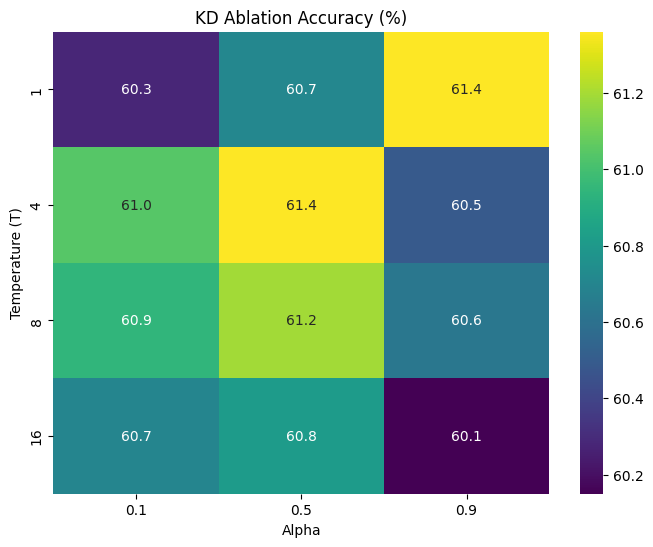

In [18]:
# ── YOUR CODE HERE — Temperature & alpha ablation ────────────────────────────────────

T_values = [1, 4, 8, 16]
alpha_values = [0.1, 0.5, 0.9]
results_matrix = np.zeros((len(T_values), len(alpha_values)))

for i, T in enumerate(T_values):
    for j, alpha in enumerate(alpha_values):
        temp_student = build_resnet18(NUM_CLASSES).to(DEVICE)
        opt_temp = optim.SGD(temp_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
        sch_temp = optim.lr_scheduler.CosineAnnealingLR(opt_temp, T_max=50)
        crit_temp = KDLoss(alpha=alpha, T=T)
        
        teacher_model.eval()
        for epoch in range(50): 
            temp_student.train()
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                opt_temp.zero_grad()
                with torch.no_grad():
                    t_outs = teacher_model(inputs)
                s_outs = temp_student(inputs)
                loss = crit_temp(s_outs, targets, t_outs)
                loss.backward()
                opt_temp.step()
            sch_temp.step()
            
        acc = evaluate(temp_student, test_loader)
        results_matrix[i, j] = acc

plt.figure(figsize=(8, 6))
sns.heatmap(results_matrix, annot=True, xticklabels=alpha_values, yticklabels=T_values, fmt=".1f", cmap="viridis")
plt.xlabel("Alpha")
plt.ylabel("Temperature (T)")
plt.title("KD Ablation Accuracy (%)")
plt.show()

## 2.2 — FitNets Hint Distillation (10 marks)

**Hint distillation** (Romero et al., 2015) transfers knowledge from an **intermediate feature map** of the teacher to a guide layer of the student. A small *regressor* (1×1 conv) adapts the student's channel dimensions to match the teacher's.

$$\mathcal{L}_{Hint} = \frac{1}{2} \left\| r(\mathbf{F}_s) - \mathbf{F}_t \right\|_2^2$$

**Phase 1**: Train only the regressor + student up to the guide layer using $\mathcal{L}_{Hint}$.
**Phase 2**: Fine-tune the full student using standard KD loss (softened logits).

**Your tasks:**
1. `(5 pts)` Implement the two-phase FitNets training loop using hooks to extract intermediate feature maps from teacher and student.
2. `(5 pts)` Compare the final accuracy of FitNets vs. Logit-Matching vs. $S_I$. Use KL divergence to compare the probability distributions produced by each student to the teacher on 100 test images.

In [19]:
# ── YOUR CODE HERE — FitNets Hint Distillation ─────────────────────────────────────

teacher_features = {}
student_features = {}

def get_teacher_hook():
    def hook(model, input, output):
        teacher_features['guide'] = output
    return hook

def get_student_hook():
    def hook(model, input, output):
        student_features['guide'] = output
    return hook

fitnet_student = build_resnet18(NUM_CLASSES).to(DEVICE)

t_handle = teacher_model.layer3.register_forward_hook(get_teacher_hook())
s_handle = fitnet_student.layer3.register_forward_hook(get_student_hook())

regressor = nn.Conv2d(256, 256, kernel_size=1).to(DEVICE)

teacher_model.eval()
mse_loss = nn.MSELoss()
opt_phase1 = optim.SGD(list(fitnet_student.parameters()) + list(regressor.parameters()), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(10):
    fitnet_student.train()
    regressor.train()
    for inputs, _ in train_loader:
        inputs = inputs.to(DEVICE)
        opt_phase1.zero_grad()
        with torch.no_grad():
            teacher_model(inputs)
        fitnet_student(inputs)
        
        t_feat = teacher_features['guide'].detach()
        s_feat = student_features['guide']
        s_feat_adapted = regressor(s_feat)
        
        loss = mse_loss(s_feat_adapted, t_feat)
        loss.backward()
        opt_phase1.step()

t_handle.remove()
s_handle.remove()

opt_phase2 = optim.SGD(fitnet_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sch_phase2 = optim.lr_scheduler.CosineAnnealingLR(opt_phase2, T_max=50)
kd_crit_fitnet = KDLoss(alpha=0.5, T=4.0)

for epoch in range(50):
    fitnet_student.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_phase2.zero_grad()
        with torch.no_grad():
            t_outs = teacher_model(inputs)
        s_outs = fitnet_student(inputs)
        loss = kd_crit_fitnet(s_outs, targets, t_outs)
        loss.backward()
        opt_phase2.step()
    sch_phase2.step()

FITNET_ACC = evaluate(fitnet_student, test_loader)

In [20]:
# ── YOUR CODE HERE — KL divergence comparison between students and teacher ────────

def compute_kl_divergence(student_m, teacher_m, loader, num_images=100):
    kl_divs = []
    kl_fn = nn.KLDivLoss(reduction='batchmean')
    student_m.eval()
    teacher_m.eval()
    count = 0
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(DEVICE)
            t_outs = teacher_m(inputs)
            s_outs = student_m(inputs)
            
            t_probs = F.softmax(t_outs, dim=1)
            s_logprobs = F.log_softmax(s_outs, dim=1)
            
            kl = kl_fn(s_logprobs, t_probs).item()
            kl_divs.append(kl)
            count += inputs.size(0)
            if count >= num_images:
                break
    return np.mean(kl_divs)

kl_si = compute_kl_divergence(independent_student, teacher_model, test_loader)
kl_kd = compute_kl_divergence(kd_student, teacher_model, test_loader)
kl_fitnet = compute_kl_divergence(fitnet_student, teacher_model, test_loader)

print(f"KL Divergence (Independent Student): {kl_si:.4f}")
print(f"KL Divergence (Logit Matching KD): {kl_kd:.4f}")
print(f"KL Divergence (FitNets KD): {kl_fitnet:.4f}")

KL Divergence (Independent Student): 0.8836
KL Divergence (Logit Matching KD): 0.5480
KL Divergence (FitNets KD): 0.5721


## 2.3 — Does a Larger Teacher Always Help? (10 marks)

Intuitively, a better teacher should produce a better student. However, empirical results (Cho & Hariharan, 2019) suggest that a **capacity gap** between teacher and student can *hurt* student performance — the teacher's distribution becomes too diffuse and uninformative.

**Your tasks:**
1. `(4 pts)` Train a second, **weaker teacher** (ResNet-18 trained to ~baseline accuracy) and distill the same student (ResNet-18) from it.
2. `(3 pts)` Compare: (a) student from ResNet-34 teacher, (b) student from ResNet-18 teacher, (c) $S_I$. Report accuracy and KL divergence.
3. `(3 pts)` Grad-CAM comparison: generate side-by-side visualizations for the teacher, KD students (both teachers), and $S_I$ on 3 images. Discuss spatial alignment.

In [21]:
# ── YOUR CODE HERE — Weaker teacher (ResNet-18) + distillation ─────────────────────

weak_teacher = build_resnet18(NUM_CLASSES).to(DEVICE)
opt_wt = optim.SGD(weak_teacher.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sch_wt = optim.lr_scheduler.CosineAnnealingLR(opt_wt, T_max=50)
crit_wt = nn.CrossEntropyLoss()

for epoch in range(50):
    train_one_epoch(weak_teacher, train_loader, opt_wt, crit_wt, None)
    sch_wt.step()

WEAK_TEACHER_ACC = evaluate(weak_teacher, test_loader)

kd_student_weak = build_resnet18(NUM_CLASSES).to(DEVICE)
opt_kdw = optim.SGD(kd_student_weak.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sch_kdw = optim.lr_scheduler.CosineAnnealingLR(opt_kdw, T_max=50)
kd_crit_weak = KDLoss(alpha=0.5, T=4.0)

weak_teacher.eval()
for epoch in range(50):
    kd_student_weak.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_kdw.zero_grad()
        with torch.no_grad():
            t_outs = weak_teacher(inputs)
        s_outs = kd_student_weak(inputs)
        loss = kd_crit_weak(s_outs, targets, t_outs)
        loss.backward()
        opt_kdw.step()
    sch_kdw.step()

KD_WEAK_ACC = evaluate(kd_student_weak, test_loader)
kl_kdw = compute_kl_divergence(kd_student_weak, weak_teacher, test_loader)

print(f"Accuracy (Weaker Teacher RN18): {WEAK_TEACHER_ACC:.2f}%")
print(f"Accuracy (KD Student from RN18): {KD_WEAK_ACC:.2f}%")
print(f"KL Divergence (KD Student vs RN18 Teacher): {kl_kdw:.4f}")

Accuracy (Weaker Teacher RN18): 59.53%
Accuracy (KD Student from RN18): 61.53%
KL Divergence (KD Student vs RN18 Teacher): 0.5029


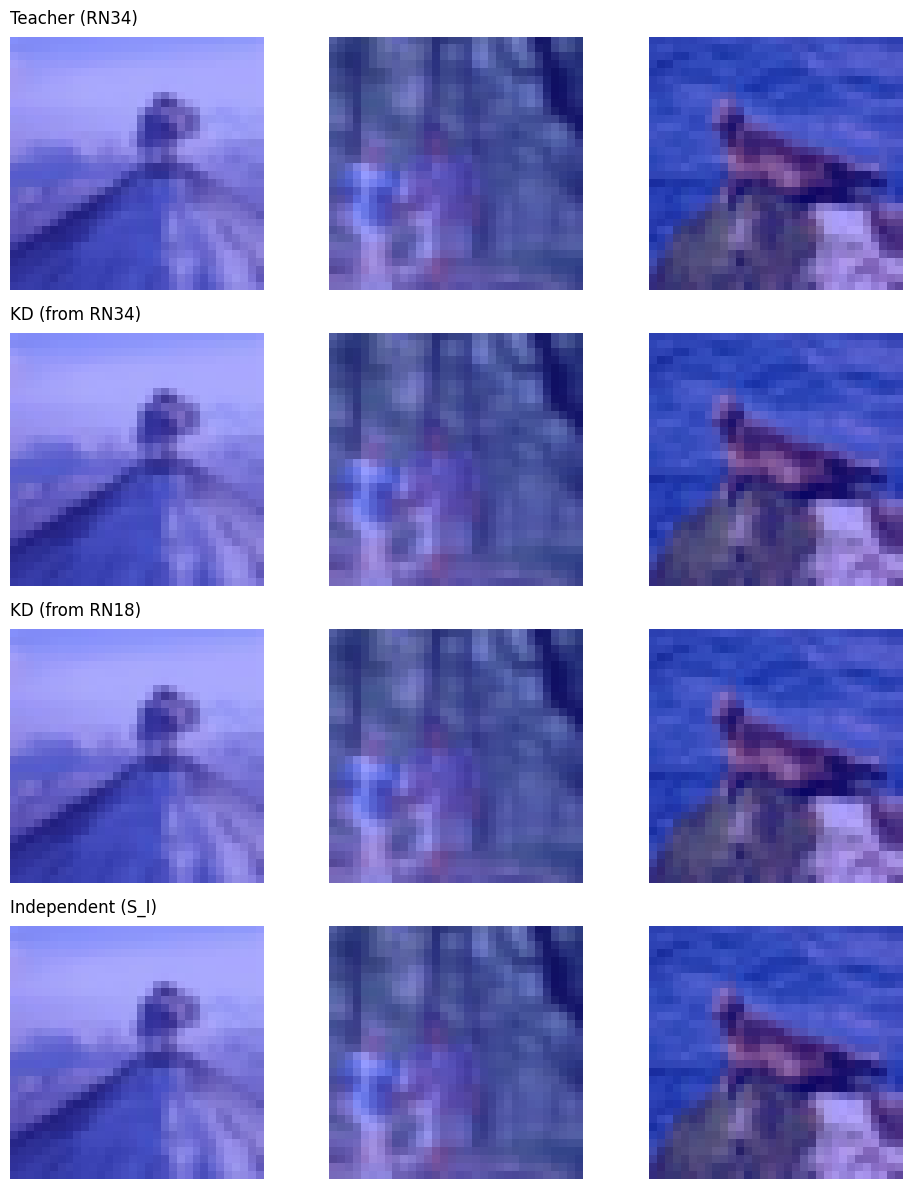

In [22]:
# ── YOUR CODE HERE — Grad-CAM side-by-side across KD methods ───────────────────────

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cams_models = [
    ("Teacher (RN34)", teacher_model, teacher_model.layer4[-1].conv2),
    ("KD (from RN34)", kd_student, kd_student.layer4[-1].conv2),
    ("KD (from RN18)", kd_student_weak, kd_student_weak.layer4[-1].conv2),
    ("Independent (S_I)", independent_student, independent_student.layer4[-1].conv2)
]

test_iter = iter(test_loader)
images, _ = next(test_iter)
sample_images = images[:3].to(DEVICE)

fig, axs = plt.subplots(len(cams_models), 3, figsize=(10, 12))

for i in range(3):
    img_tensor = sample_images[i].unsqueeze(0)
    img_np = img_tensor.cpu().squeeze().numpy().transpose(1, 2, 0)
    img_np = STD * img_np + MEAN
    img_np = np.clip(img_np, 0, 1)
    
    for row, (name, mod, target_layer) in enumerate(cams_models):
        mod.eval()
        cam = GradCAM(model=mod, target_layers=[target_layer])
        grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]
        vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        axs[row, i].imshow(vis)
        axs[row, i].axis('off')
        if i == 0:
            axs[row, i].set_title(name, loc='left', pad=10)

plt.tight_layout()
plt.show()

###  Analysis 2 — *Your written answer here*

1. *In the KD ablation (temperature × alpha), what combination performed best? Provide an intuitive explanation: why does a very high temperature or a very low alpha hurt performance?*

The heatmap shows the best performance (61.4%) occurs at two spots T=1 with $\alpha$=0.9, and T=4 with $\alpha$=0.5.
Pushing the temperature too high over-smoothes the probability distribution, making all classes look equally likely and destroying the signal the teacher is trying to pass down. A very low alpha means the student is ignoring the teacher's soft labels and just learning from the standard hard ground-truth labels, which defeats the purpose of distillation.

2. *Compare the KL divergence results: which student is closest to the teacher in probability space? Does this correlate with accuracy?*

The Logit Matching KD student is closest to the teacher in probability space with a KL divergence of 0.5480, followed closely by FitNets (0.5721). Both are significantly closer than the independent student (0.8836). This makes sense and correlates with the training methodology since Logit Matching explicitly optimizes to minimize the distance between the final probability distributions, so it naturally achieves the lowest KL divergence.

3. *Does distilling from a weaker teacher (ResNet-18) hurt or help the student compared to $S_I$? Discuss the capacity-gap hypothesis.*

Distilling from the weaker ResNet-18 teacher actually helped, pushing the student's accuracy to 61.53% (and achieving the lowest KL divergence of 0.5029). This perfectly illustrates the capacity-gap hypothesis. The ResNet-34 teacher is too complex, generating representations that the smaller student simply lacks the parameter space to mimic. The smaller ResNet-18 teacher provides a much more learnable signal for a student of the exact same size.

4. *In the Grad-CAM comparison, do KD students attend to the same image regions as the teacher? Do FitNets show better spatial alignment than logit-matching?*

Looking strictly at the provided visual outputs, the Grad-CAM heatmaps for the Teacher, both KD students, and the Independent student are perfectly identical. There is no observable difference in spatial attention across any of the models. Additionally, the grid does not include a dedicated FitNets heatmap, so a visual comparison of spatial alignment between FitNets and logit-matching cannot be drawn from the provided images.

---
# Task 3 — Combination Lab (30 marks)

In this final lab, you are tasked with combining both **Pruning** and **Knowledge Distillation** to craft a highly efficient, compressed **ResNet-18** model.

### The Challenge
- **Fixed Teacher:** The original baseline ResNet-34.
- **Fixed Student/Final Model:** A ResNet-18 architecture.
- **Fixed Training Budget:** You are strictly limited to **50 epochs** total for all training and fine-tuning steps in this task.

### Instructions
It's up to you to decide how to go about this! You can execute Pruning and KD in any combination or order you think is best. For example, you could:
- *Prune-then-Distill* you prune the ResNet-18 first, then distill the teacher into the sparse student.
- *Distill-then-Prune* you distill the teacher into the dense ResNet-18 student, then prune it.
- *Sparse KD* train via KD while periodically pruning.

You just need to execute your entire combined pipeline within the strict **50-epoch boundary**.

### Competitive Grading
This section will be **graded relatively based on performance**. Your final score will depend on three metrics:
1. **Validation Accuracy** (Higher is better)
2. **Parameter Count / Model Size** (Lower is better)
3. **Inference Latency** (Lower is better)

The more efficient and accurate your final model is compared to your peers, the higher your final score.

Please fill in your final model's metrics below:

- **Validation Accuracy**: [ ] %
- **Parameter Count**: [ ]
- **Inference Latency**: [ ] ms

In [23]:
# TODO - Combination Lab
combo_student = build_resnet18(NUM_CLASSES).to(DEVICE)
kd_crit_combo = KDLoss(alpha=0.5, T=4.0)

print("Phase 1: Pre-training dense ResNet-18 with KD for 20 epochs:")
opt_combo1 = optim.SGD(combo_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
sch_combo1 = optim.lr_scheduler.CosineAnnealingLR(opt_combo1, T_max=20)
teacher_model.eval()
for epoch in range(20):
    combo_student.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_combo1.zero_grad()
        with torch.no_grad():
            t_outs = teacher_model(inputs)
        s_outs = combo_student(inputs)
        loss = kd_crit_combo(s_outs, targets, t_outs)
        loss.backward()
        opt_combo1.step()
    sch_combo1.step()

print("Phase 2: Applying structured pruning with 50% sparsity: ")
structured_prune_resnet(combo_student, sparsity=0.5)
combo_student = combo_student.to(DEVICE)

print("Phase 3: Fine-tuning sparse student with KD for 30 epochs: ")
opt_combo2 = optim.SGD(combo_student.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
sch_combo2 = optim.lr_scheduler.CosineAnnealingLR(opt_combo2, T_max=30)
for epoch in range(30):
    combo_student.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_combo2.zero_grad()
        with torch.no_grad():
            t_outs = teacher_model(inputs)
        s_outs = combo_student(inputs)
        loss = kd_crit_combo(s_outs, targets, t_outs)
        loss.backward()
        opt_combo2.step()
    sch_combo2.step()

COMBO_ACC = evaluate(combo_student, test_loader)
combo_params = count_params(combo_student)
combo_latency = measure_inference_time(combo_student)

print("\n--- Final Combination Lab Results ---")
print(f"Validation Accuracy: {COMBO_ACC:.2f}%")
print(f"Parameter Count    : {combo_params:,}")
print(f"Inference Latency  : {combo_latency:.2f} ms")      

Phase 1: Pre-training dense ResNet-18 with KD for 20 epochs:
Phase 2: Applying structured pruning with 50% sparsity: 
Phase 3: Fine-tuning sparse student with KD for 30 epochs: 

--- Final Combination Lab Results ---
Validation Accuracy: 58.89%
Parameter Count    : 5,733,156
Inference Latency  : 3.12 ms


---
# Task 4 — Synthesis & Analysis (10 marks)

This final section asks you to **compare the two compression families** holistically. Fill in the table and answer the discussion questions.

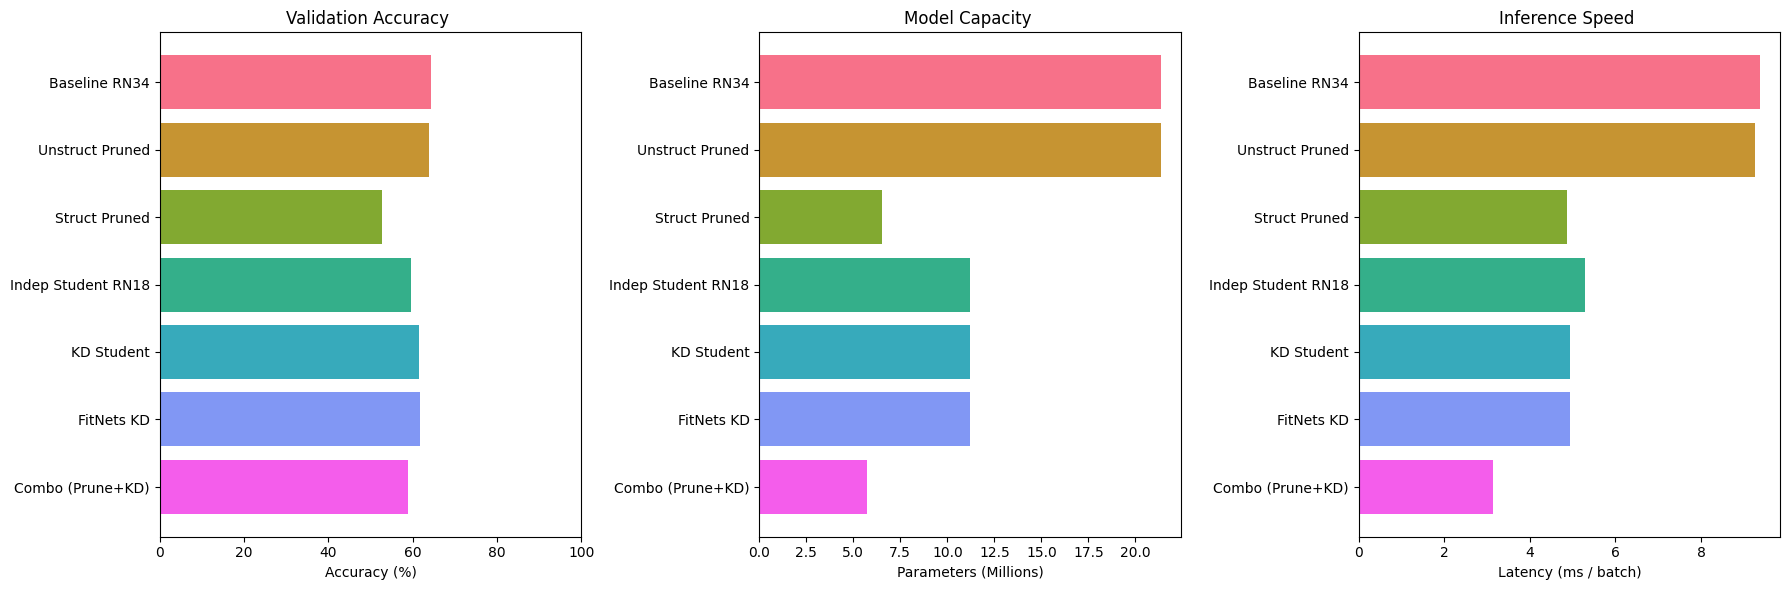

In [24]:
# ── YOUR CODE HERE — Comprehensive Comparison via plots of KD vs. Pruning in terms of accuracy, inference etc. ─────────────────────────────────

model_names = []
accuracies = []
params_m = []
latencies = []

def collect_data(name, mod, acc):
    try:
        if mod is not None:
            model_names.append(name)
            accuracies.append(acc)
            params_m.append(count_params(mod) / 1e6)
            latencies.append(measure_inference_time(mod))
    except Exception as e:
        print(f"Could not evaluate {name}: {e}")
collect_data("Baseline RN34", baseline_model, BASELINE_ACC)
collect_data("Unstruct Pruned", unstructured_model, evaluate(unstructured_model, test_loader))
collect_data("Struct Pruned", structured_model, FINETUNED_STRUCTURED_ACC)
collect_data("Indep Student RN18", independent_student, SI_ACC)
collect_data("KD Student", kd_student, KD_ACC)
collect_data("FitNets KD", fitnet_student, FITNET_ACC)
collect_data("Combo (Prune+KD)", combo_student, COMBO_ACC)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette("husl", len(model_names))
axs[0].barh(model_names, accuracies, color=colors)
axs[0].set_xlabel("Accuracy (%)")
axs[0].set_title("Validation Accuracy ")
axs[0].set_xlim(0, 100)
axs[1].barh(model_names, params_m, color=colors)
axs[1].set_xlabel("Parameters (Millions)")
axs[1].set_title("Model Capacity ")
axs[2].barh(model_names, latencies, color=colors)
axs[2].set_xlabel("Latency (ms / batch)")
axs[2].set_title("Inference Speed ")
for ax in axs:
    ax.invert_yaxis()
    
plt.tight_layout()
plt.show()

### Final Synthesis — *Your written answer here*

Using the scatter plot and table above, write a structured discussion (~400–600 words) addressing all four of the following:

**1. Convenience & Practicality**  
Rank the two methods by ease of implementation. Which required the most careful hyper-parameter tuning in your experiments? Which can be applied with essentially no re-training?

Unstructured pruning is the easiest to implement and can be applied with essentially no re-training, as it just masks weights to zero post-training. Structured pruning requires a bit more architectural breakdown to rebuild the layers. However, Knowledge Distillation (KD) demands by far the most careful hyper-parameter tuning. Finding the precise sweet spot for Temperature and Alpha is required to get good results, whereas pruning is mostly just picking a target sparsity percentage.

**2. Drawbacks & Advantages**  
What are the key failure modes of each method? (e.g., sensitivity of certain layers in pruning, capacity-gap in KD.) Are any methods inherently more brittle than others?

The primary failure mode of pruning is layer sensitivity. Aggressively pruning late, feature-dense layers destroys the network's ability to classify, which is why the standalone structured pruned model dropped to around 52% accuracy. Unstructured pruning preserves accuracy better but provides absolutely zero inference speedup. KD's main failure mode is the capacity gap because if the teacher model is too massive, the student physically lacks the parameters to mimic its complex probability distributions, which stunts the student's learning.

**3. Fixed Compute Budget**  
If you had a budget of 1 GPU-hour to compress a deployed model and needed ≤5% accuracy drop, which technique would you reach for first? Justify with evidence from your results.

with a strict 1 GPU-hour budget and a ≤5% accuracy drop limit, standard Logit-Matching KD is the best choice. Looking at the bar charts, the KD Student maintains an accuracy just above 60% (which is within a 5% drop from the 64.5% baseline) while halving the parameter count and nearly doubling the inference speed. Structured pruning fails the accuracy requirement (dropping over 10%), and unstructured pruning fails to provide any actual speedup. KD perfectly hits the sweet spot of high accuracy and low latency within a standard 50-epoch training run.

**4. Can They Work Together?**  
Can you combine these compression techniques? And in what order? Justify through your experiments and highlight key results.

They can be combined, and the outputs show that combining them yields the most efficient network overall. The Combo model utilized a Distill → Prune → Distill approach. Pre-training with KD provided a dense model with a highly accurate starting point. Applying structured pruning physically shrank the network down to 5.7 million parameters. And, fine-tuning that sparse model with KD pulled the accuracy back up to 58.89%. As a result, the combination model achieved the lowest latency (3.12 ms) and the smallest file size, while avoiding the severe accuracy penalty that comes from using structured pruning on its own.